In [74]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

### Data Import

In [75]:
PROJECT_ROOT = Path("../")

FEATURE_PATH = (
    PROJECT_ROOT /
    "data" /
    "features" /
    "customer_ml_features.csv"
)


customers_ml = pd.read_csv(FEATURE_PATH)

### Dataset Overview

In [76]:
customers_ml.head()

,customer_unique_id,recency_days,frequency,monetary,avg_order_value,total_items,unique_categories,unique_sellers,avg_review_score,late_delivery_ratio,total_payment_value,avg_payment_value,avg_installments,max_installments,payment_method_count,preferred_payment_type,state,latitude,longitude,churn_label
0,7c396fd4830fd04220f754e42b4e5bff,380,2,82.82,41.41,2,2,2,4.5,0.0,82.82,41.41,1.0,1.0,1,credit_card,SP,-23.577482,-46.587077,1
1,af07308b275d755c9edb36a90c618231,84,1,141.46,141.46,1,1,1,4.0,0.0,141.46,141.46,1.0,1.0,1,boleto,BA,-12.186877,-44.540232,0
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,179.12,179.12,1,1,1,5.0,0.0,179.12,179.12,3.0,3.0,1,credit_card,GO,-16.745150,-48.514783,0
3,7c142cf63193a1473d2e66489a9ae977,332,1,72.20,72.20,1,1,1,5.0,0.0,72.20,72.20,1.0,1.0,1,credit_card,RN,-5.774002,-35.270976,1
4,72632f0f9dd73dfee390c9b22eb56dd6,245,1,28.62,28.62,1,1,1,5.0,0.0,28.62,28.62,1.0,1.0,1,credit_card,SP,-23.676257,-46.514580,1


In [77]:
customers_ml.shape

(96096, 20)

In [78]:
customers_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_unique_id      96096 non-null  str    
 1   recency_days            96096 non-null  int64  
 2   frequency               96096 non-null  int64  
 3   monetary                96096 non-null  float64
 4   avg_order_value         96096 non-null  float64
 5   total_items             96096 non-null  int64  
 6   unique_categories       96096 non-null  int64  
 7   unique_sellers          96096 non-null  int64  
 8   avg_review_score        96096 non-null  float64
 9   late_delivery_ratio     96096 non-null  float64
 10  total_payment_value     96096 non-null  float64
 11  avg_payment_value       96096 non-null  float64
 12  avg_installments        96096 non-null  float64
 13  max_installments        96096 non-null  float64
 14  payment_method_count    96096 non-null  int64  
 

In [79]:
# Check for missing values in the dataset
missing = (
    customers_ml
    .isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)


missing[missing > 0]

Series([], dtype: int64)

In [80]:
# Validate that the number of unique customer IDs matches the number of rows in the dataset
customers_ml["customer_unique_id"].nunique() == len(customers_ml)

True

### Target Distribution

In [81]:
customers_ml["churn_label"].value_counts()

churn_label
1    68115
0    27981
Name: count, dtype: int64

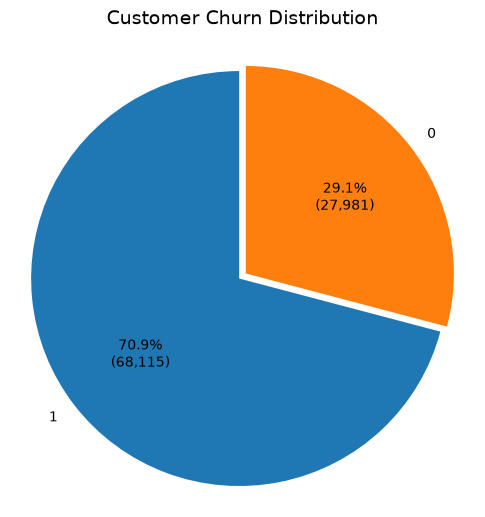

In [82]:
plt.figure(figsize=(6, 6))

churn_counts = customers_ml["churn_label"].value_counts()

def autopct_with_count(pct):
    count = int(round(pct / 100 * churn_counts.sum()))
    return f"{pct:.1f}%\n({count:,})"

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct=autopct_with_count,
    startangle=90,
    explode=[0.02] * len(churn_counts)
)

plt.title(
    "Customer Churn Distribution",
    fontsize=14,
    pad=15
)

plt.axis("equal")

plt.show()

### VIsualization - Churn vs Active Customers

### Recency

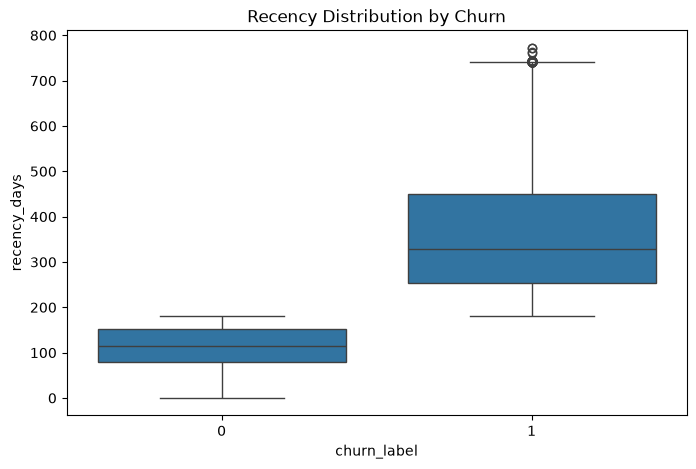

In [84]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customers_ml,
    x="churn_label",
    y="recency_days"
)

plt.title(
    "Recency Distribution by Churn"
)

plt.show()

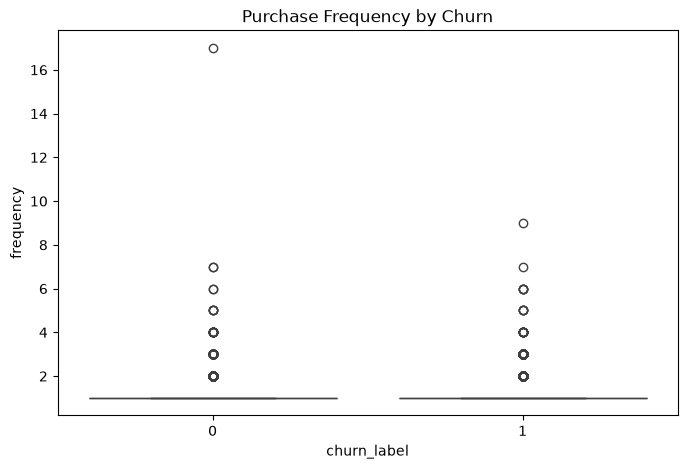

In [85]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customers_ml,
    x="churn_label",
    y="frequency"
)

plt.title(
    "Purchase Frequency by Churn"
)

plt.show()

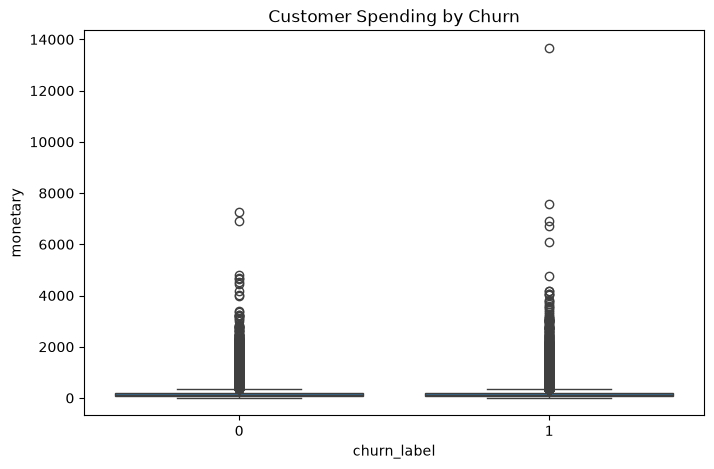

In [86]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customers_ml,
    x="churn_label",
    y="monetary"
)

plt.title(
    "Customer Spending by Churn"
)

plt.show()

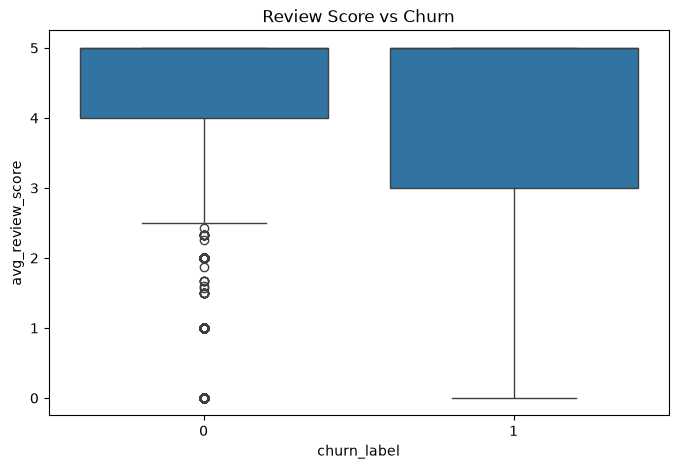

In [87]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customers_ml,
    x="churn_label",
    y="avg_review_score"
)

plt.title(
    "Review Score vs Churn"
)

plt.show()

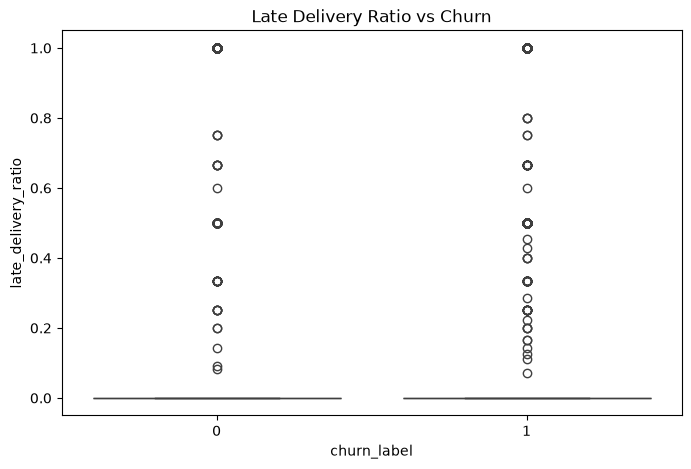

In [88]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customers_ml,
    x="churn_label",
    y="late_delivery_ratio"
)

plt.title(
    "Late Delivery Ratio vs Churn"
)

plt.show()

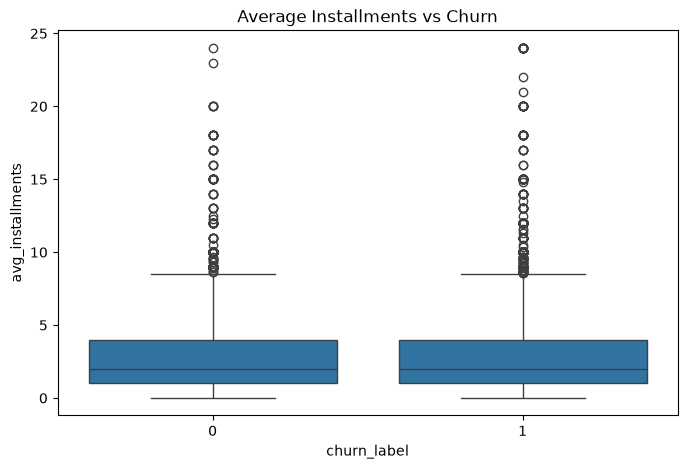

In [89]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customers_ml,
    x="churn_label",
    y="avg_installments"
)

plt.title(
    "Average Installments vs Churn"
)

plt.show()

In [90]:
payment_churn = (

    customers_ml.groupby(
        [
        "preferred_payment_type",
        "churn_label"
        ]
    ).size().reset_index(
        name="customers"
    )

)


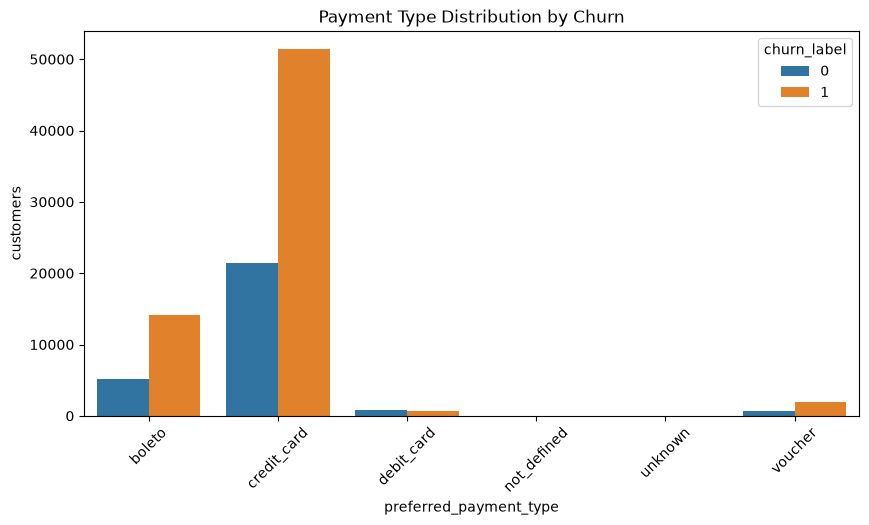

In [91]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=payment_churn,
    x="preferred_payment_type",
    y="customers",
    hue="churn_label"
)

plt.xticks(rotation=45)

plt.title(
    "Payment Type Distribution by Churn"
)

plt.show()

In [92]:
state_churn = (

    customers_ml.groupby("state")["churn_label"].mean().sort_values(ascending=False)

)

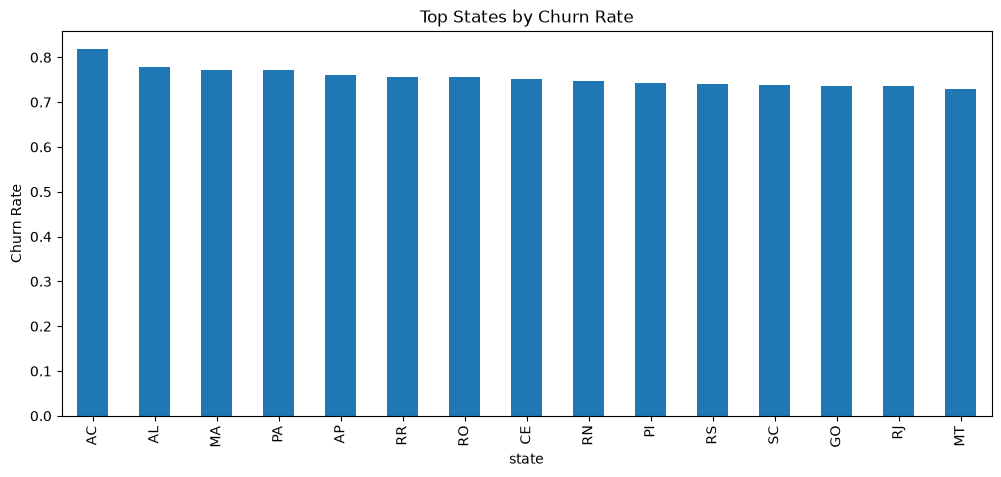

In [93]:
plt.figure(figsize=(12,5))

state_churn.head(15).plot(
    kind="bar"
)

plt.title(
    "Top States by Churn Rate"
)

plt.ylabel(
    "Churn Rate"
)

plt.show()

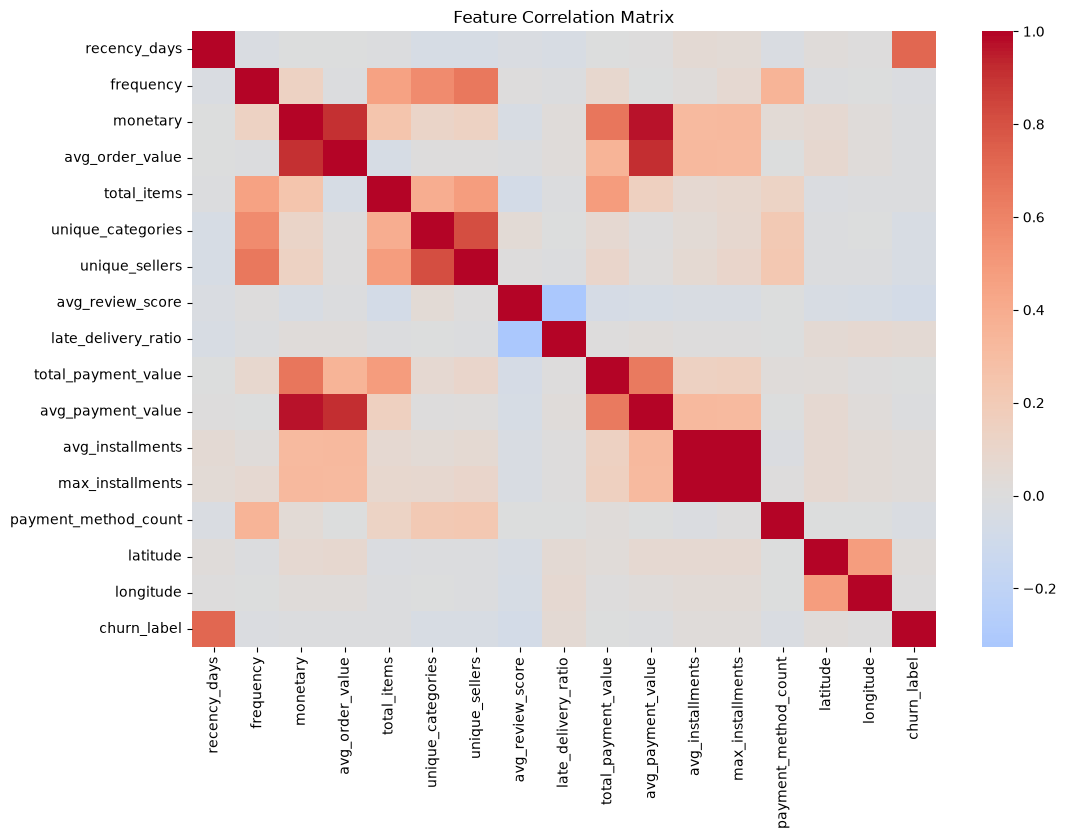

In [94]:
numeric_features = customers_ml.select_dtypes(include=np.number)

corr = numeric_features.corr()

corr["churn_label"].sort_values(ascending=False)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

In [95]:
upper_triangle = corr.where(
    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)
)

high_corr = [

column

for column in upper_triangle.columns

if any(
    abs(upper_triangle[column]) > 0.8
)

]

high_corr

['avg_order_value', 'unique_sellers', 'avg_payment_value', 'max_installments']

In [96]:
customers_ml.select_dtypes(
    include="object"
).columns

C:\Users\cjc72\AppData\Local\Temp\ipykernel_5584\701489364.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  customers_ml.select_dtypes(


Index(['customer_unique_id', 'preferred_payment_type', 'state'], dtype='str')

#### Churn Analysis Summary

- **Recency is the strongest differentiating feature**, with churned customers showing significantly longer inactivity periods (~359 days) compared to active customers (~115 days). This is due to the threshold (>180 = churn) set up previously.

- **Purchase behaviour is largely similar** between churned and active customers, with minimal differences in frequency, total spending, average order value, and product diversity.

- **Customer satisfaction shows a slight decline among churned customers**, with lower average review scores (3.99 vs 4.22) and a higher late delivery ratio (8.7% vs 6.0%).

- Overall, churn appears to be mainly associated with **customer inactivity and service experience issues**, while historical spending behaviour provides limited separation between churned and active customers.

In [97]:
selected_features = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_order_value",

    "frequency",
    "unique_categories",
    "unique_sellers",

    "avg_review_score",
    "late_delivery_ratio",

    "avg_installments",
    "max_installments",
    "payment_method_count",

    "preferred_payment_type",

    "state",
    "latitude",
    "longitude"
]


target = "churn_label"

In [98]:
EDA_DIR = PROJECT_ROOT / "data" / "features"

EDA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

customers_ml[
    selected_features + [target]
].to_csv(
    EDA_DIR / "customer_churn_dataset.csv",
    index=False
)